In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score, f1_score

from xgboost import XGBClassifier


In [2]:
df = pd.read_csv("data/raw/ai_maintaindataset.csv")
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df = df.rename(columns={
    'Air temperature [K]': 'temperature',
    'Rotational speed [rpm]': 'vibration',
    'Torque [Nm]': 'pressure',
    'Machine failure': 'target'
})


In [4]:
df = df.dropna(subset=['target'])
df['target'] = df['target'].replace({'No': 0, 'Yes': 1})
df['target'] = df['target'].astype(int)


In [5]:
df['target'].isna().sum()
df['target'].unique()
df['target'].dtype


dtype('int64')

In [6]:
df['target'].value_counts(dropna=False)


target
0    9661
1     339
Name: count, dtype: int64

In [7]:
df = df.interpolate()


C:\Users\Asus\AppData\Local\Temp\ipykernel_6888\2541859223.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate()


In [8]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.corr()



,UDI,temperature,Process temperature [K],vibration,pressure,Tool wear [min],target,TWF,HDF,PWF,OSF,RNF
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954
temperature,0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
vibration,-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
pressure,0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
target,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009154,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,-0.022215,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,-0.023557,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273


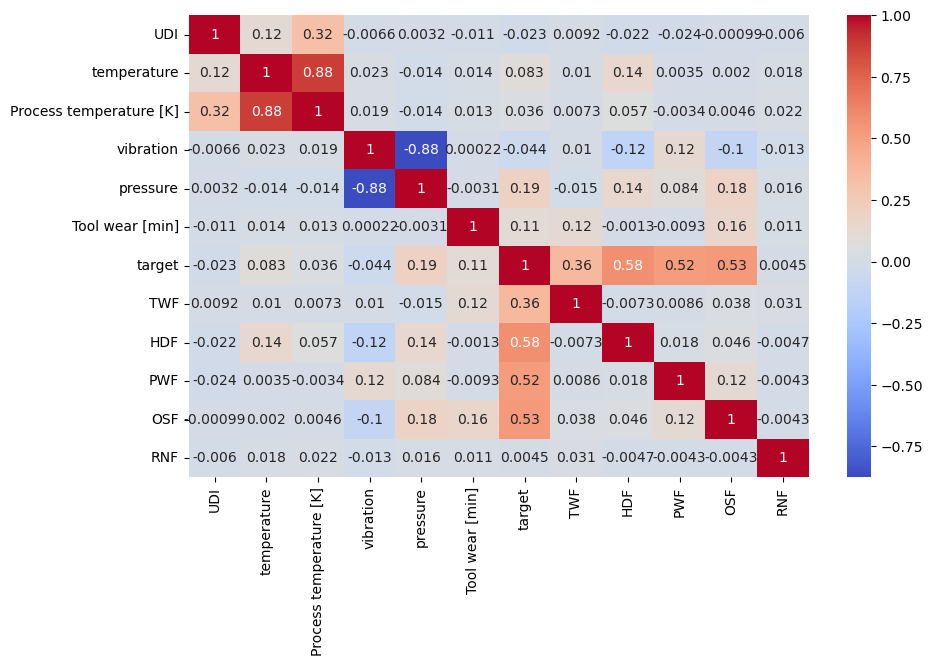

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()


In [10]:
df['temp_roll_mean_3'] = df['temperature'].rolling(window=3, min_periods=1).mean()
df['vib_roll_std_3'] = df['vibration'].rolling(window=3, min_periods=1).std()


In [11]:
df = df.dropna()
print(df.shape)


(9999, 16)


In [12]:
X = df.drop(columns=['target'])
X = X.select_dtypes(include=['number'])
y = df['target']


In [13]:
list(X_train.columns)


NameError: name 'X_train' is not defined

In [15]:
X.columns = (
    X.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)


In [17]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
##Evaluation – Logistic Regressionabs
print(classification_report(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1961
           1       1.00      0.95      0.97        39

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Recall: 0.9487179487179487
F1: 0.9736842105263158


In [19]:
##Random FOrest
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [20]:
print(classification_report(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1961
           1       1.00      0.95      0.97        39

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Recall: 0.9487179487179487
F1: 0.9736842105263158


In [21]:
##xg boost
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


In [22]:
print(y_train.unique())
print(y_train.dtype)


[0 1]
int64


In [23]:
print(classification_report(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1961
           1       1.00      0.95      0.97        39

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Recall: 0.9487179487179487
F1: 0.9736842105263158


In [24]:
import shap
shap.initjs()



In [25]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

##Computes feature contribution values
#For every prediction, it explains how much each feature pushed the decision


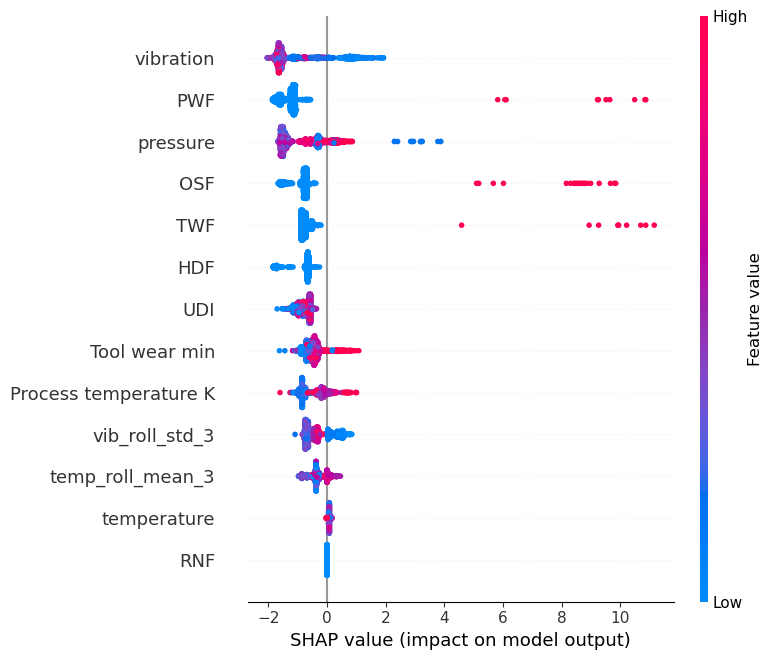

In [26]:
#Understand which features are most important overall.
shap.summary_plot(shap_values, X_test)


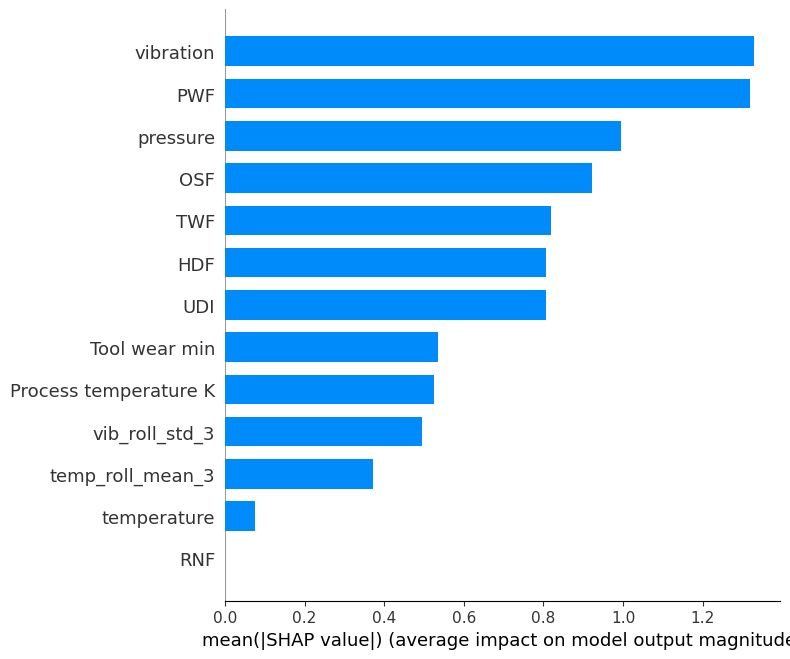

In [27]:
shap.summary_plot(shap_values, X_test, plot_type="bar")


In [28]:
index = 0  # any test sample
shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    X_test.iloc[index]
)


In [29]:
import joblib

joblib.dump(xgb, "xgb_model.pkl")


['xgb_model.pkl']

In [31]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load trained model
model = joblib.load("xgb_model.pkl")

st.set_page_config(page_title="FactoryGuard AI", layout="centered")

st.title("🛠️ FactoryGuard AI")
st.subheader("Predictive Maintenance System")

st.write("Enter machine sensor values to predict failure risk.")

# Input fields
vibration = st.number_input("Vibration", min_value=0.0, value=1.5)
pressure = st.number_input("Pressure", min_value=0.0, value=50.0)
temperature = st.number_input("Temperature", min_value=0.0, value=300.0)

pwf = st.selectbox("Power Failure (PWF)", [0, 1])
osf = st.selectbox("Overstrain Failure (OSF)", [0, 1])
twf = st.selectbox("Tool Wear Failure (TWF)", [0, 1])
hdf = st.selectbox("Heat Dissipation Failure (HDF)", [0, 1])

# Create input DataFrame
input_data = pd.DataFrame({
    "vibration": [vibration],
    "pressure": [pressure],
    "temperature": [temperature],
    "PWF": [pwf],
    "OSF": [osf],
    "TWF": [twf],
    "HDF": [hdf]
})

# Predict
if st.button("Predict Failure"):
    probability = model.predict_proba(input_data)[0][1]
    prediction = "FAILURE" if probability > 0.5 else "NO FAILURE"

    st.success(f"Prediction: {prediction}")
    st.info(f"Failure Probability: {probability:.2f}")


2026-01-09 20:03:12.366 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-09 20:03:12.367 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-09 20:03:12.368 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-09 20:03:12.368 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-09 20:03:12.369 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-09 20:03:12.370 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-09 20:03:12.371 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-09 20:03:12.371 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar